In [1]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Dự liệu sử dụng người dùng trên website.xlsx')
print(df.head())

  Mã người dùng  Thời gian ở lại  Số trang xem  Tỷ lệ quay lại
0          U001               26            14            0.33
1          U002              665            10            0.08
2          U003              244             6            0.70
3          U004              737             2            0.10
4          U005              154            17            0.85


In [2]:
# 2: Làm sạch dữ liệu
# Đặt lại tên cột cho dễ dùng
df.columns = ["ma_nguoi_dung", "thoi_gian_o_lai", "so_trang_xem", "ty_le_quay_lai"]

# Kiểm tra giá trị thiếu
print("Số lượng giá trị thiếu:\n", df.isnull().sum())

# Chuẩn hóa kiểu dữ liệu về dạng số
df["thoi_gian_o_lai"] = pd.to_numeric(df["thoi_gian_o_lai"], errors="coerce")
df["so_trang_xem"] = pd.to_numeric(df["so_trang_xem"], errors="coerce")
df["ty_le_quay_lai"] = pd.to_numeric(df["ty_le_quay_lai"], errors="coerce")

# In ra dữ liệu sau khi đã làm sạch
print("\nDữ liệu sau khi làm sạch:")
print(df.head(20))

Số lượng giá trị thiếu:
 ma_nguoi_dung      0
thoi_gian_o_lai    0
so_trang_xem       0
ty_le_quay_lai     0
dtype: int64

Dữ liệu sau khi làm sạch:
   ma_nguoi_dung  thoi_gian_o_lai  so_trang_xem  ty_le_quay_lai
0           U001               26            14            0.33
1           U002              665            10            0.08
2           U003              244             6            0.70
3           U004              737             2            0.10
4           U005              154            17            0.85
5           U006              478             7            0.37
6           U007              774            16            0.73
7           U008              284             8            0.99
8           U009              640            12            0.87
9           U010               12            11            0.54
10          U011              521            19            0.66
11          U012              229             5            0.82
12          U013   

Thống kê mô tả cơ bản
       thoi_gian_o_lai  so_trang_xem  ty_le_quay_lai
count       250.000000    250.000000       250.00000
mean        444.048000     10.316000         0.48964
std         249.088873      5.504301         0.27779
min          12.000000      1.000000         0.00000
25%         229.750000      6.000000         0.27000
50%         454.500000     10.000000         0.50500
75%         667.250000     15.000000         0.72000
max         894.000000     20.000000         1.00000

Chỉ số chi tiết:

Biến: thoi_gian_o_lai
Trung bình: 444.048
Trung vị: 454.5
Phương sai: 62045.266763052205
Giá trị nhỏ nhất: 12
Giá trị lớn nhất: 894

Biến: so_trang_xem
Trung bình: 10.316
Trung vị: 10.0
Phương sai: 30.297333333333356
Giá trị nhỏ nhất: 1
Giá trị lớn nhất: 20

Biến: ty_le_quay_lai
Trung bình: 0.48963999999999996
Trung vị: 0.505
Phương sai: 0.07716733975903615
Giá trị nhỏ nhất: 0.0
Giá trị lớn nhất: 1.0


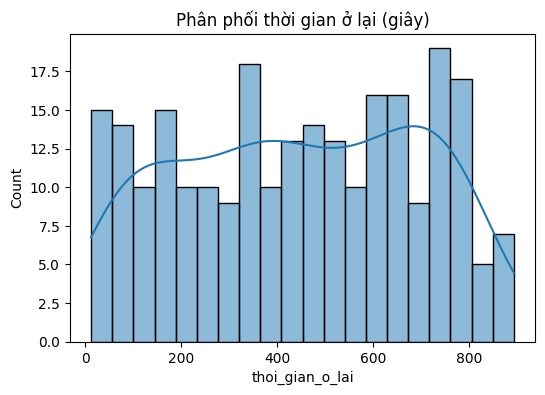

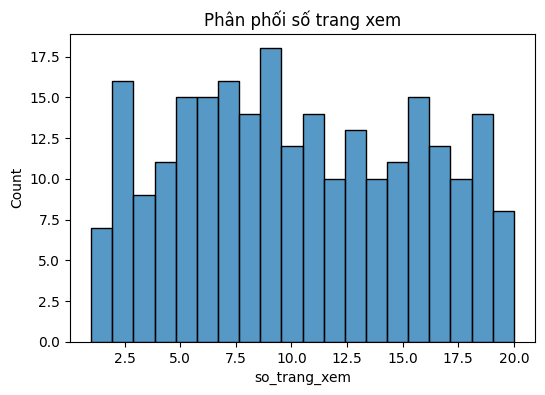

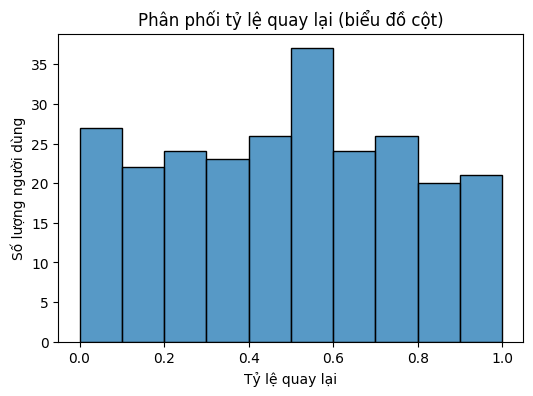

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3: Phân tích khám phá dữ liệu (EDA)
print("Thống kê mô tả cơ bản")
print(df.describe())

# In thêm các chỉ số riêng lẻ
print("\nChỉ số chi tiết:")
for col in ["thoi_gian_o_lai", "so_trang_xem", "ty_le_quay_lai"]:
    print(f"\nBiến: {col}")
    print("Trung bình:", df[col].mean())
    print("Trung vị:", df[col].median())
    print("Phương sai:", df[col].var())
    print("Giá trị nhỏ nhất:", df[col].min())
    print("Giá trị lớn nhất:", df[col].max())

# Biểu đồ phân phối thời gian ở lại
plt.figure(figsize=(6,4))
sns.histplot(df["thoi_gian_o_lai"], bins=20, kde=True)
plt.title("Phân phối thời gian ở lại (giây)")
plt.show()

# Biểu đồ phân phối số trang xem
plt.figure(figsize=(6,4))
sns.histplot(df["so_trang_xem"], bins=20, kde=False)
plt.title("Phân phối số trang xem")
plt.show()

# Biểu đồ tỷ lệ quay lại
plt.figure(figsize=(6,4))
sns.histplot(df["ty_le_quay_lai"], bins=10, kde=False)
plt.title("Phân phối tỷ lệ quay lại (biểu đồ cột)")
plt.xlabel("Tỷ lệ quay lại")
plt.ylabel("Số lượng người dùng")
plt.show()

Hồi quy tuyến tính: thời gian ở lại và tỷ lệ quay lại
Phương trình hồi quy: y = 0.46 + 0.00x
Hệ số chặn (beta_0): 0.45708459255301637
Hệ số dốc (beta_1): 7.331506379261607e-05
Hệ số xác định (R^2): 0.004321769109158158
Sai số bình phương trung bình (MSE): 0.0765265049724943


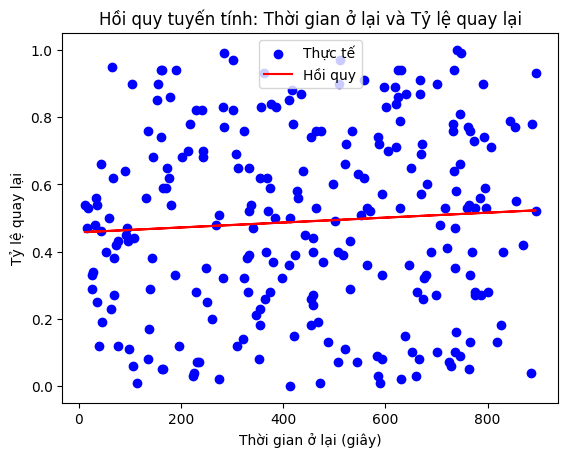


Hồi quy tuyến tính: số trang xem và tỷ lệ quay lại
Phương trình hồi quy: y = 0.53 + -0.00x
Hệ số chặn (beta_0): 0.5278756941244712
Hệ số dốc (beta_1): -0.003706445727459412
Hệ số xác định (R^2): 0.005393692295520003
Sai số bình phương trung bình (MSE): 0.0764441183816196


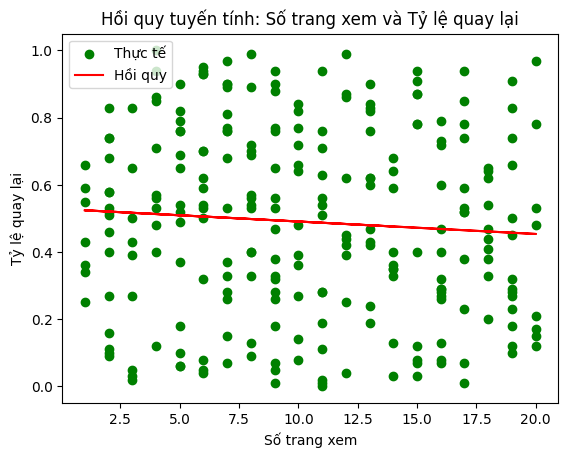

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 4. Xây dựng mô hình
y = df["ty_le_quay_lai"]

# Hồi quy tuyến tính: dự đoán từ thời gian ở lại
X1 = df["thoi_gian_o_lai"].values.reshape(-1,1)
model1 = LinearRegression()
model1.fit(X1, y)
y_pred1 = model1.predict(X1)

beta_0 = model1.intercept_
beta_1 = model1.coef_[0]
r2 = r2_score(y, y_pred1)
mse = mean_squared_error(y, y_pred1)

print("Hồi quy tuyến tính: thời gian ở lại và tỷ lệ quay lại")
print(f"Phương trình hồi quy: y = {beta_0:.2f} + {beta_1:.2f}x")
print(f"Hệ số chặn (beta_0): {beta_0}")
print(f"Hệ số dốc (beta_1): {beta_1}")
print(f"Hệ số xác định (R^2): {r2}")
print(f"Sai số bình phương trung bình (MSE): {mse}")

plt.scatter(X1, y, color="blue", label="Thực tế")
plt.plot(X1, y_pred1, color="red", label="Hồi quy")
plt.title("Hồi quy tuyến tính: Thời gian ở lại và Tỷ lệ quay lại")
plt.xlabel("Thời gian ở lại (giây)")
plt.ylabel("Tỷ lệ quay lại")
plt.legend()
plt.show()

# Hồi quy tuyến tính: dự đoán từ số trang xem
X2 = df["so_trang_xem"].values.reshape(-1,1)
model2 = LinearRegression()
model2.fit(X2, y)
y_pred2 = model2.predict(X2)

beta_0 = model2.intercept_
beta_1 = model2.coef_[0]
r2 = r2_score(y, y_pred2)
mse = mean_squared_error(y, y_pred2)

print("\nHồi quy tuyến tính: số trang xem và tỷ lệ quay lại")
print(f"Phương trình hồi quy: y = {beta_0:.2f} + {beta_1:.2f}x")
print(f"Hệ số chặn (beta_0): {beta_0}")
print(f"Hệ số dốc (beta_1): {beta_1}")
print(f"Hệ số xác định (R^2): {r2}")
print(f"Sai số bình phương trung bình (MSE): {mse}")

plt.scatter(X2, y, color="green", label="Thực tế")
plt.plot(X2, y_pred2, color="red", label="Hồi quy")
plt.title("Hồi quy tuyến tính: Số trang xem và Tỷ lệ quay lại")
plt.xlabel("Số trang xem")
plt.ylabel("Tỷ lệ quay lại")
plt.legend()
plt.show()

 5. Phân tích kết quả
 - Thời gian ở lại trung bình của người dùng: Khoảng 444.05 giây.
 - Số trang xem trung bình: Khoảng 10.32 trang mỗi phiên.
 - Mối quan hệ yếu: Cả ba mô hình hồi quy tuyến tính:
    - Mô hình 1 (Thời gian ở lại): R^2 là 0.0043, chứng tỏ thời gian ở lại chỉ giải thích được khoảng 0.43% sự biến động của tỷ lệ quay lại. Hệ số dốc (beta_1 = 7.33e-05) rất nhỏ, cho thấy ảnh hưởng không đáng kể.
    - Mô hình 2 (Số trang xem): R^2 là 0.0054, cho thấy số trang xem chỉ giải thích được khoảng 0.54% sự biến động của tỷ lệ quay lại. Hệ số dốc (beta_1 = -0.0037) cũng rất nhỏ, chỉ ra mối quan hệ nghịch biến rất yếu.
  - Kết luận: nhận định đúng rằng các mô hình hồi quy tuyến tính hiện tại không có khả năng dự đoán tốt tỷ lệ quay lại của người dùng. R^2 cực thấp trong tất cả các trường hợp cho thấy rằng 'thời gian ở lại' và 'số trang xem' không phải là những yếu tố dự đoán mạnh mẽ cho 'tỷ lệ quay lại' theo mối quan hệ tuyến tính.
- Những điểm cần cải thiện:
  - Mối quan hệ yếu: Các biến đã phân tích có mối quan hệ tuyến tính rất yếu với tỷ lệ quay lại.
  - Thiếu yếu tố quan trọng: Có thể các yếu tố chính ảnh hưởng đến tỷ lệ quay lại chưa được đưa vào phân tích.
- Các cách cải thiện:
  - Bổ sung các biến mới: Thu thập và đưa vào mô hình các biến khác có thể liên quan chặt chẽ hơn đến hành vi quay lại của người dùng (ví dụ: đặc điểm người dùng, nguồn giới thiệu, lịch sử tương tác, loại nội dung, tương tác tính năng).
  - Sử dụng mô hình phức tạp hơn: Nếu mối quan hệ không tuyến tính, cần xem xét các thuật toán học máy phi tuyến tính hoặc nâng cao như Cây quyết định, Rừng ngẫu nhiên, Gradient Boosting hoặc Mạng nơ-ron để nắm bắt các mối quan hệ phức tạp hơn.
  - Phân tích hành vi sâu hơn: Phân khúc người dùng và phân tích riêng cho từng nhóm có thể giúp hiểu rõ hơn về các mẫu hành vi khác nhau.